ECB Speeches

In [2]:
from pathlib import Path
import pandas as pd
import fredapi
from fredapi import Fred

Importing Fred Data

Inflation

In [ ]:
# Api Key
fred_api_key = Fred(api_key='88a8844ca93e8780390f1ea6641677f3')
# Start Dates
start_date = "2000-01-01"
# End Dates
end_date = "2026-01-01"
inflation_data_ids = {"US_Annual_CPI": "FPCPITOTLZGUSA", "Ten_Yr_US_Brk_even": "T10YIEM"}
# Making the data frame
raw_monthly_inflation_data = pd.concat({name: fred_api_key.get_series(sid, observation_start=start_date, observation_end=end_date)
    for name, sid in inflation_data_ids.items()},
    axis=1
)
# Converting the raw monthly data into daily data and keeping the time frame consistent with the rest of the data
daily_inflation_data = raw_monthly_inflation_data.resample('M').ffill()
daily_inflation_data

/var/folders/k1/mhyzg0w15gb04d0x6q7gdp2w0000gn/T/ipykernel_59197/448790437.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  daily_inflation_data = raw_monthly_inflation_data.resample('M').ffill()


,US_Annual_CPI,Ten_Yr_US_Brk_even
2000-01-31,3.376857,NaN
2000-02-29,3.376857,NaN
2000-03-31,3.376857,NaN
2000-04-30,3.376857,NaN
2000-05-31,3.376857,NaN
...,...,...
2025-09-30,NaN,2.37
2025-10-31,NaN,2.31
2025-11-30,NaN,2.27
2025-12-31,NaN,2.24


Unemployment

In [11]:
# Api Key
fred_api_key = Fred(api_key='88a8844ca93e8780390f1ea6641677f3')
# Start Dates
start_date = "2000-01-01"
# End Dates
end_date = "2026-01-01"
emply_data_ids = {"US_Unemploy": "UNRATE",}
# Making the data frame
raw_monthly_unemploy_data = pd.concat({name: fred_api_key.get_series(sid, observation_start=start_date, observation_end=end_date)
    for name, sid in emply_data_ids.items()},
    axis=1
)
# Converting the raw monthly data into daily data and keeping the time frame consistent with the rest of the data
daily_unemploy_data = raw_monthly_unemploy_data.resample('M').ffill()
daily_unemploy_data

/var/folders/k1/mhyzg0w15gb04d0x6q7gdp2w0000gn/T/ipykernel_59197/848946646.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  daily_unemploy_data = raw_monthly_unemploy_data.resample('M').ffill()


,US_Unemploy
2000-01-31,4.0
2000-02-29,4.1
2000-03-31,4.0
2000-04-30,3.8
2000-05-31,4.0
...,...
2025-09-30,4.4
2025-10-31,NaN
2025-11-30,4.5
2025-12-31,4.4


Merged on Date Hawkish, Dovish Dataframe

In [14]:
fomc_announcment_path = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/FED/Annotated/FOMC STATEMENTS")
fomc_pressconf_path = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/FED/Annotated/Press Conferences")
fomc_speech_path = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/FED/Annotated/Speeches/Annotated with Shah Merge/")

fomc_announcment = pd.read_excel(fomc_announcment_path/ "fomc_statements_train_1000.xls")
fomc_pressconf = pd.read_excel(fomc_pressconf_path / "presconf_to_annotate.xlsx")
fomc_speech = pd.read_excel(fomc_speech_path / "lab-manual-sp-train-5768-augmented.xlsx")



In [ ]:
fomc_announcment.head(10)

,id,raw_text,doc_type,clean_text,sentence,label,date,exact_match
0,1556,Information received since the Federal Open Ma...,statement,Information received since the Federal Open Ma...,"Currently, the unemployment rate is elevated, ...",MD,2010-11-03,True
1,526,Information received since the Federal Open Ma...,statement,Information received since the Federal Open Ma...,Market-based measures of inflation compensatio...,N,2020-01-29,True
2,393,The Federal Reserve is committed to using its ...,statement,The Federal Reserve is committed to using its ...,"Last December, the Committee indicated that it...",D,2021-07-28,True
3,1789,The Federal Open Market Committee decided toda...,statement,The Federal Open Market Committee decided toda...,"Still, possible increases in resource utilizat...",MH,2006-05-10,True
4,433,The Federal Reserve is committed to using its ...,statement,The Federal Reserve is committed to using its ...,Weaker demand and earlier declines in oil pric...,MD,2021-01-27,True
5,1159,Information received since the Federal Open Ma...,statement,Information received since the Federal Open Ma...,To support continued progress toward maximum e...,D,2014-07-30,True
6,1090,Information received since the Federal Open Ma...,statement,Information received since the Federal Open Ma...,When the Committee decides to begin to remove ...,MH,2015-01-28,True
7,429,The Federal Reserve is committed to using its ...,statement,The Federal Reserve is committed to using its ...,The Committee would be prepared to adjust the ...,N,2021-03-17,True
8,1802,"Release Date: December 13, 2005 \n\nFor immedi...",statement,"Release Date: December 13, 2005 For immediate ...","Nevertheless, possible increases in resource u...",MH,2005-12-13,True
9,530,Information received since the Federal Open Ma...,statement,Information received since the Federal Open Ma...,The Committee will continue to monitor the imp...,N,2020-01-29,True


In [16]:
fomc_pressconf.head(10)

,date,file,speaker,sentence,label,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,These projections are conditional on each part...,N,NaN,NaN,N,507.0
1,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,"Perhaps most important, attempting to maintain...",D,NaN,NaN,H,248.0
2,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,"Indeed, most central banks around the world ai...",N,NaN,NaN,D,243.0
3,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,"For example, the unemployment rate moved down ...",H,NaN,NaN,NaN,NaN
4,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,the markdown of growth in 2011 in particular r...,D,NaN,NaN,NaN,NaN
5,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,The outlook for above-trend growth is associat...,H,NaN,NaN,NaN,NaN
6,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,"At 8.8 percent, the current unemployment rate ...",D,NaN,NaN,NaN,NaN
7,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,The substantial ongoing slack in the labor mar...,D,NaN,NaN,NaN,NaN
8,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,"Importantly, however, the Committee’s outlook ...",H,NaN,NaN,NaN,NaN
9,2011-04-27,2011-04-27-presconf.txt,CHAIRMAN BERNANKE,The Committee remains confident that it has th...,N,NaN,NaN,NaN,NaN


In [17]:
fomc_speech.head(10)

,sentence,year,label,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,"Moreover, we should recognize that these disin...",2021,D,NaN,N,520.0
1,There are a variety of versions of this basic ...,2004,N,NaN,D,201.0
2,"Of the 1,700 Washington employees, roughly 250...",2002,N,NaN,H,230.0
3,It is again useful to compare estimates of exp...,2020,H,NaN,NaN,NaN
4,Estimates by the staff of the Federal Reserve ...,1997,H,NaN,NaN,NaN
5,"As a case in point, the increase in the transp...",2017,N,NaN,NaN,NaN
6,That's why I said that flexibility is also an ...,2005,D,NaN,NaN,NaN
7,"Moreover, investing in EMEs has become more at...",2006,N,NaN,NaN,NaN
8,"Of course, the basic problem in tackling the i...",2002,H,NaN,NaN,NaN
9,"In the absence of legislation, going appreciab...",2022,D,NaN,NaN,NaN


Creating the Index

--- statements ---
columns: ['id', 'raw_text', 'doc_type', 'clean_text', 'sentence', 'label', 'date', 'exact_match']
     id                                           raw_text   doc_type  \
0  1556  Information received since the Federal Open Ma...  statement   
1   526  Information received since the Federal Open Ma...  statement   
2   393  The Federal Reserve is committed to using its ...  statement   

                                          clean_text  \
0  Information received since the Federal Open Ma...   
1  Information received since the Federal Open Ma...   
2  The Federal Reserve is committed to using its ...   

                                            sentence label       date  \
0  Currently, the unemployment rate is elevated, ...    MD 2010-11-03   
1  Market-based measures of inflation compensatio...     N 2020-01-29   
2  Last December, the Committee indicated that it...     D 2021-07-28   

   exact_match  
0         True  
1         True  
2         True  

---

/var/folders/k1/mhyzg0w15gb04d0x6q7gdp2w0000gn/T/ipykernel_59197/4217743240.py:52: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  counts = df.groupby([pd.Grouper(key="date", freq=freq), "label"]).size().unstack(fill_value=0)
/var/folders/k1/mhyzg0w15gb04d0x6q7gdp2w0000gn/T/ipykernel_59197/4217743240.py:52: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  counts = df.groupby([pd.Grouper(key="date", freq=freq), "label"]).size().unstack(fill_value=0)


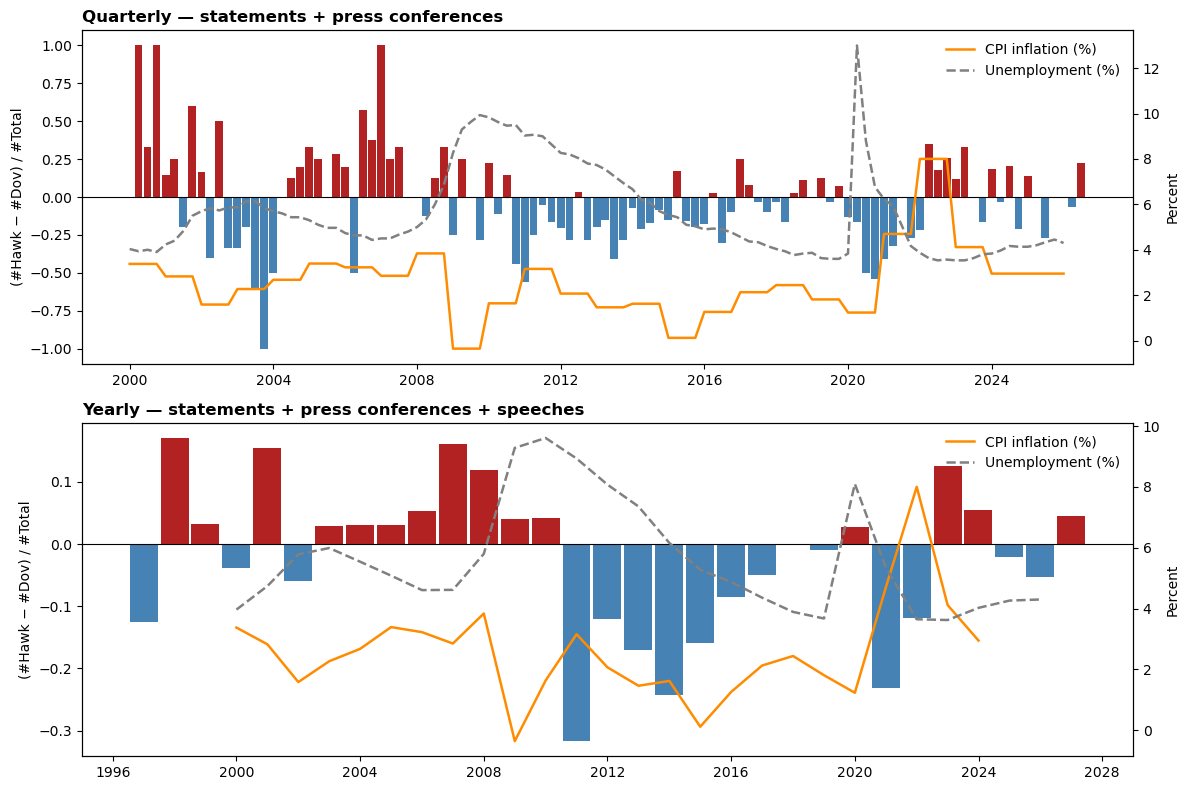

In [25]:
# %% [markdown]
# ### Hawkish–Dovish index
# Measure = (#Hawkish − #Dovish) / #Total
# Quarterly: statements + press conferences | Yearly: + speeches

# %%
import matplotlib.pyplot as plt

# --- edit these three lines if your column names differ ---
DATE_COL  = "date"    # date column in the statements & press conference files
YEAR_COL  = "year"    # the speeches file only has the year
LABEL_COL = "label"   # 0 = dovish, 1 = hawkish, 2 = neutral

def clean_label(x):
    code = str(x).strip().upper()
    if code in ("H", "MH"):   # hawkish, mildly hawkish
        return "hawkish"
    if code in ("D", "MD"):   # dovish, mildly dovish
        return "dovish"
    if code == "N":           # neutral
        return "neutral"
    return None

# %% [markdown]
# ### Diagnostic — run this if the counts above come back empty
# Paste the printed output back so the column names / label mapping can be fixed.

# %%
for name, df in [("statements", fomc_announcment), ("press conferences", fomc_pressconf), ("speeches", fomc_speech)]:
    print(f"--- {name} ---")
    print("columns:", list(df.columns))
    print(df.head(3))
    print()

# %%
stmts = pd.DataFrame({"date":  pd.to_datetime(fomc_announcment[DATE_COL], errors="coerce"),
                      "label": fomc_announcment[LABEL_COL].map(clean_label)}).dropna()

pressc = pd.DataFrame({"date":  pd.to_datetime(fomc_pressconf[DATE_COL], errors="coerce"),
                       "label": fomc_pressconf[LABEL_COL].map(clean_label)}).dropna()

speech = pd.DataFrame({"date":  pd.to_datetime(fomc_speech[YEAR_COL].astype(int).astype(str), format="%Y"),
                       "label": fomc_speech[LABEL_COL].map(clean_label)}).dropna()

# quick sanity check — if a file shows 0 sentences, its column names above are wrong
for name, df in [("statements", stmts), ("press conferences", pressc), ("speeches", speech)]:
    print(f"{name}: {len(df)} sentences  {df['label'].value_counts().to_dict()}")

# %%
def build_index(df, freq):
    """Measure per period. freq: 'Q' = quarterly, 'A' = yearly."""
    counts = df.groupby([pd.Grouper(key="date", freq=freq), "label"]).size().unstack(fill_value=0)
    index = (counts.get("hawkish", 0) - counts.get("dovish", 0)) / counts.sum(axis=1)
    return index

quarterly = build_index(pd.concat([stmts, pressc]), "Q")
yearly    = build_index(pd.concat([stmts, pressc, speech]), "A")

# if either of these prints 0, go back and check the sanity-check counts above —
# it means the label mapping didn't match anything for one of the files
print("quarterly points:", quarterly.dropna().shape[0])
print("yearly points:", yearly.dropna().shape[0])

macro   = pd.concat([raw_monthly_inflation_data, raw_monthly_unemploy_data], axis=1)
macro_q = macro.resample("QS").mean().ffill()   # ffill because the CPI series is annual
macro_y = macro.resample("YS").mean()

# %%
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

panels = [(axes[0], quarterly, macro_q, 80,  "Quarterly — statements + press conferences"),
          (axes[1], yearly,    macro_y, 330, "Yearly — statements + press conferences + speeches")]

for ax, index, m, width, title in panels:
    ax.bar(index.index, index.values, width=width,
           color=["firebrick" if v >= 0 else "steelblue" for v in index])
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_ylabel("(#Hawk − #Dov) / #Total")

    axr = ax.twinx()
    axr.plot(m.index, m["US_Annual_CPI"], color="darkorange", lw=1.8, label="CPI inflation (%)")
    axr.plot(m.index, m["US_Unemploy"],  color="grey", ls="--", lw=1.8, label="Unemployment (%)")
    axr.set_ylabel("Percent")
    axr.legend(loc="upper right", frameon=False)

fig.tight_layout()
plt.show()

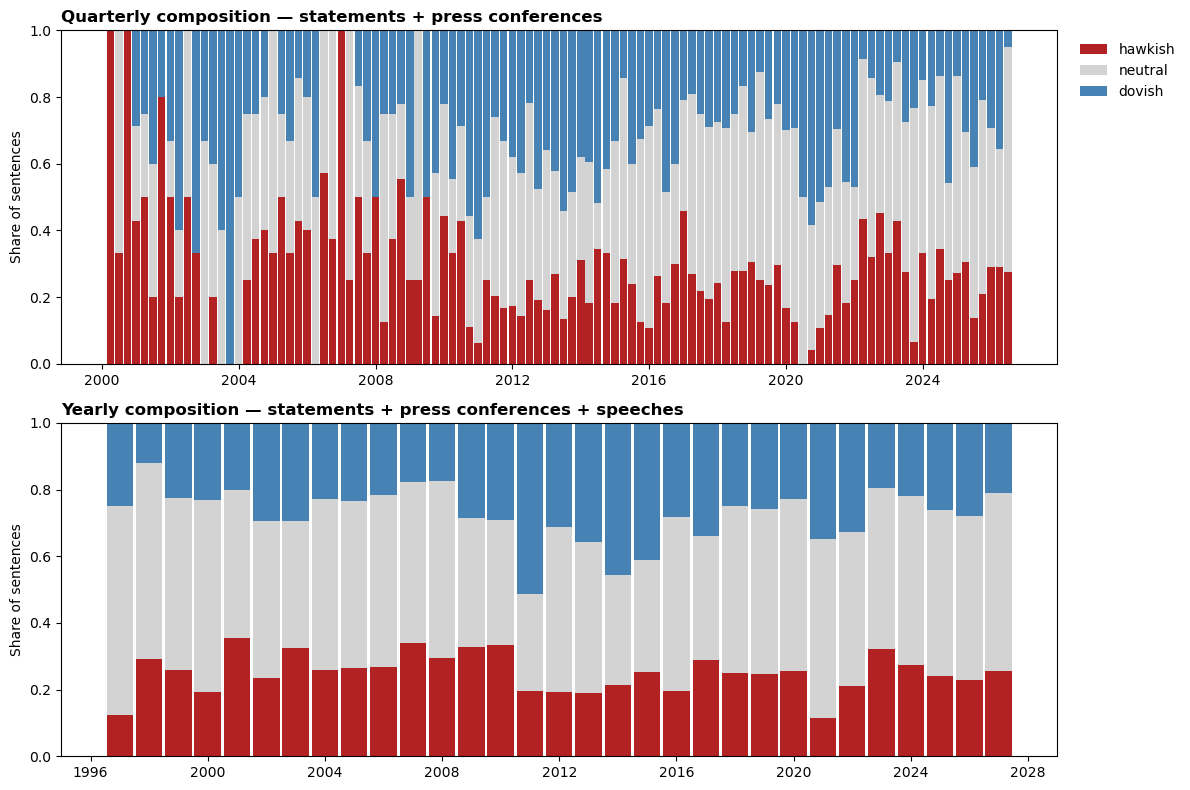

In [27]:
def build_composition(df, freq):
    counts = df.groupby([pd.Grouper(key="date", freq=freq), "label"]).size().unstack(fill_value=0)
    counts = counts.reindex(columns=["hawkish", "neutral", "dovish"], fill_value=0)
    return counts.div(counts.sum(axis=1), axis=0)   # row-normalize to proportions
 
quarterly_comp = build_composition(pd.concat([stmts, pressc]), "QE")
yearly_comp    = build_composition(pd.concat([stmts, pressc, speech]), "YE")
 
# %%
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
colors = {"hawkish": "firebrick", "neutral": "lightgrey", "dovish": "steelblue"}
 
for ax, comp, width, title in [
    (axes[0], quarterly_comp, 80,  "Quarterly composition — statements + press conferences"),
    (axes[1], yearly_comp,    330, "Yearly composition — statements + press conferences + speeches"),
]:
    bottom = pd.Series(0.0, index=comp.index)
    for label in ["hawkish", "neutral", "dovish"]:
        ax.bar(comp.index, comp[label], width=width, bottom=bottom,
               color=colors[label], label=label)
        bottom += comp[label]
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_ylabel("Share of sentences")
    ax.set_ylim(0, 1)
 
axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
fig.tight_layout()
plt.show()

ECB

In [35]:
# Paths 
ECB_announcment_path = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/ECB/Annotated")
ECB_pressconf_path = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/ECB/Annotated/")

# Reading the data frames
ecb_announcment = pd.read_excel(ECB_announcment_path / "ecb_train-2.xls", header=1)
ecb_pressconf = pd.read_excel(ECB_pressconf_path / "ecb_Press Conference Statements + Q&A_to_annotate.xlsx")


In [30]:
ecb_announcment.head(10)

,ecb_train,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,id,source_file,date,doc_type,sentence,label,final_label,NaN,NaN,NaN
1,457,2021/2021-10-28-ecb-mp.txt,28/10/2021,statement,The Governing Council will purchase flexibly a...,H,H,NaN,MD,72.0
2,289,2017/2017-07-20-ecb-mp.txt,20/07/2017,statement,"If the outlook becomes less favourable, or if ...",D,D,NaN,MH,45.0
3,323,2018/2018-09-13-ecb-mp.txt,13/09/2018,statement,At today's meeting the Governing Council of th...,MD,MD,NaN,H,88.0
4,31,2000/2000-03-16-ecb-mp.txt,16/03/2000,statement,Today's increase in ECB interest rates follows...,D,D,NaN,D,108.0
5,428,2021/2021-07-22-ecb-mp.txt,22/07/2021,statement,"In its recent strategy review, the Governing C...",N,N,NaN,N,202.0
6,198,2012/2012-04-04-ecb-mp.txt,04/04/2012,statement,At today's meeting the Governing Council of th...,N,N,NaN,NaN,NaN
7,482,2022/2022-02-03-ecb-mp.txt,03/02/2022,statement,In line with the step-by-step reduction in ass...,H,H,NaN,NaN,NaN
8,174,2011/2011-04-07-ecb-mp.txt,07/04/2011,statement,At today's meeting the Governing Council of th...,N,N,NaN,NaN,NaN
9,507,2022/2022-04-14-ecb-mp.txt,14/04/2022,statement,Inflation has increased significantly and will...,MH,MH,NaN,NaN,NaN


In [33]:
ecb_pressconf.head(10)

,date,file,title,sentence,label
0,1998-06-09,1998/1998-06-09-is.txt,ECB Press conference: Introductory statement,In subsequent meetings of the Executive Board ...,N
1,1998-06-09,1998/1998-06-09-is.txt,ECB Press conference: Introductory statement,"In other words, each national central bank may...",N
2,1998-07-08,1998/1998-07-08-is.txt,ECB Press conference: Introductory statement,Further details are provided in the separate p...,N
3,1998-07-08,1998/1998-07-08-is.txt,ECB Press conference: Introductory statement,The Governing Council considered that giving s...,N
4,1998-07-08,1998/1998-07-08-is.txt,ECB Press conference: Introductory statement,There is currently no sign of exchange rate te...,N
5,1998-07-08,1998/1998-07-08-is.txt,ECB Press conference: Introductory statement,In connection with the setting-up of common ma...,N
6,1998-07-08,1998/1998-07-08-is.txt,ECB Press conference: Introductory statement,"Second, most Member States need to go a step f...",N
7,1998-07-08,1998/1998-07-08-is.txt,ECB Press conference: Introductory statement,"It is evident, however, that economic growth a...",D
8,1998-07-08,1998/1998-07-08-is.txt,ECB Press conference: Introductory statement,Among the three main functions that a minimum ...,D
9,1998-09-11,1998/1998-09-11-is.txt,ECB Press conference: Introductory statement,One focal aspect of the discussion has been a ...,N


Fred ECB Macro Data

--- ECB announcements ---
columns: ['id', 'source_file', 'date', 'doc_type', 'sentence', 'label', 'final_label', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']
    id                 source_file        date   doc_type  \
0  457  2021/2021-10-28-ecb-mp.txt  28/10/2021  statement   
1  289  2017/2017-07-20-ecb-mp.txt  20/07/2017  statement   
2  323  2018/2018-09-13-ecb-mp.txt  13/09/2018  statement   

                                            sentence label final_label  \
0  The Governing Council will purchase flexibly a...     H           H   
1  If the outlook becomes less favourable, or if ...     D           D   
2  At today's meeting the Governing Council of th...    MD          MD   

   Unnamed: 7 Unnamed: 8  Unnamed: 9  
0         NaN         MD        72.0  
1         NaN         MH        45.0  
2         NaN          H        88.0  

--- ECB press conferences ---
columns: ['date', 'file', 'title', 'sentence', 'label']
         date                    file  \
0  1998-06-09  1998

/var/folders/k1/mhyzg0w15gb04d0x6q7gdp2w0000gn/T/ipykernel_59197/2820247201.py:35: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  "date":  pd.to_datetime(ecb_announcment[ECB_DATE_COL], errors="coerce"),


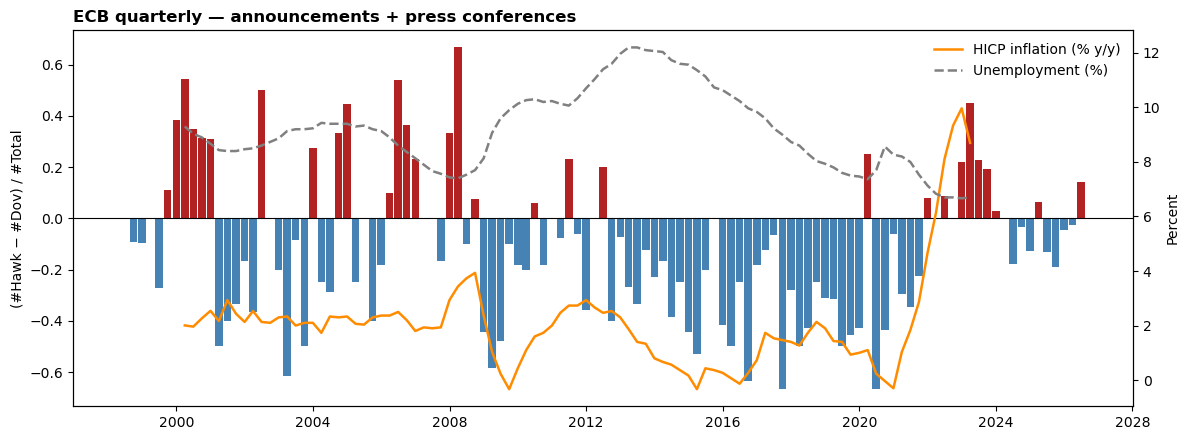

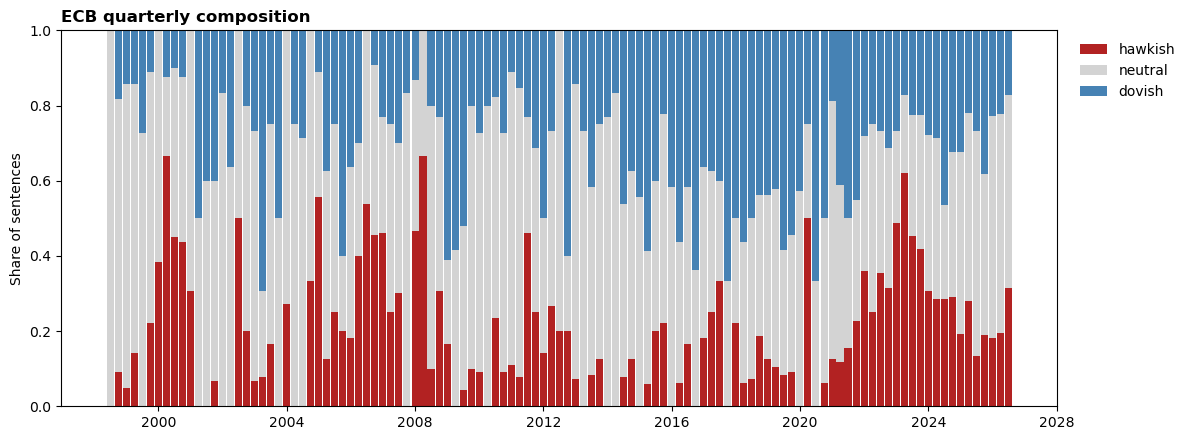

In [36]:
ea_ids = {
    "EA_HICP_YoY":  "EA19CPALTT01GYM",   # Euro area HICP, % change y/y, monthly
    "EA_Unemploy":  "LRHUTTTTEZM156S",   # Euro area harmonised unemployment rate, monthly
}
raw_ecb_macro = pd.concat(
    {name: fred_api_key.get_series(sid, observation_start=start_date, observation_end=end_date)
     for name, sid in ea_ids.items()},
    axis=1
)
ecb_macro = raw_ecb_macro.resample("ME").ffill()
ecb_macro
 
 
# %% [markdown]
# ### Diagnostic — check column names / label values before mapping
# (ECB files may not use the same column names or label codes as the FOMC ones)
 
# %%
for name, df in [("ECB announcements", ecb_announcment), ("ECB press conferences", ecb_pressconf)]:
    print(f"--- {name} ---")
    print("columns:", list(df.columns))
    print(df.head(3))
    print()
 
# %% [markdown]
# ### Fix these once the diagnostic output above tells you the real names
# (start from the FOMC clean_label — same H/D/N-with-M-prefix scheme is likely,
# but confirm against the printed label values first)
 
# %%
ECB_DATE_COL  = "date"    # <- update from diagnostic output
ECB_LABEL_COL = "label"   # <- update from diagnostic output
 
ecb_stmts = pd.DataFrame({
    "date":  pd.to_datetime(ecb_announcment[ECB_DATE_COL], errors="coerce"),
    "label": ecb_announcment[ECB_LABEL_COL].map(clean_label)
}).dropna()
 
ecb_pressc = pd.DataFrame({
    "date":  pd.to_datetime(ecb_pressconf[ECB_DATE_COL], errors="coerce"),
    "label": ecb_pressconf[ECB_LABEL_COL].map(clean_label)
}).dropna()
 
for name, df in [("ECB announcements", ecb_stmts), ("ECB press conferences", ecb_pressc)]:
    print(f"{name}: {len(df)} sentences  {df['label'].value_counts().to_dict()}")
 
# %% [markdown]
# ### Build the ECB index (quarterly only — no ECB speeches file given)
 
# %%
ecb_quarterly = build_index(pd.concat([ecb_stmts, ecb_pressc]), "QE")
ecb_macro_q = ecb_macro.resample("QE").mean().ffill()
 
# %%
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(ecb_quarterly.index, ecb_quarterly.values, width=80,
       color=["firebrick" if v >= 0 else "steelblue" for v in ecb_quarterly])
ax.axhline(0, color="black", lw=0.8)
ax.set_title("ECB quarterly — announcements + press conferences", loc="left", fontweight="bold")
ax.set_ylabel("(#Hawk − #Dov) / #Total")
 
axr = ax.twinx()
axr.plot(ecb_macro_q.index, ecb_macro_q["EA_HICP_YoY"], color="darkorange", lw=1.8, label="HICP inflation (% y/y)")
axr.plot(ecb_macro_q.index, ecb_macro_q["EA_Unemploy"], color="grey", ls="--", lw=1.8, label="Unemployment (%)")
axr.set_ylabel("Percent")
axr.legend(loc="upper right", frameon=False)
 
fig.tight_layout()
plt.show()
 
# %% [markdown]
# ### ECB composition chart
 
# %%
ecb_quarterly_comp = build_composition(pd.concat([ecb_stmts, ecb_pressc]), "QE")
 
fig, ax = plt.subplots(figsize=(12, 4.5))
bottom = pd.Series(0.0, index=ecb_quarterly_comp.index)
for label in ["hawkish", "neutral", "dovish"]:
    ax.bar(ecb_quarterly_comp.index, ecb_quarterly_comp[label], width=80, bottom=bottom,
           color=colors[label], label=label)
    bottom += ecb_quarterly_comp[label]
ax.set_title("ECB quarterly composition", loc="left", fontweight="bold")
ax.set_ylabel("Share of sentences")
ax.set_ylim(0, 1)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
fig.tight_layout()
plt.show()